<h2 style="color:blue" align="center">Handwritten digits classification using CNN</h2>

- In this notebook we will classify handwritten digits using a **Simple neural network (ANN)** first and than repeat same thing with **Convolutional neural network**. We will see how accuracy improves clickly when you use convolutional neural network.

- Here we need to read handwritten digit from 0 to 9

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [26]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [27]:
X_train.shape

(60000, 28, 28)

> 60000 handwritten digit image, each of size 28*28 dimension. here RGB value is not there, its a black and white image

> In case of other execrcise it was like this (10000, 32, 32, 3)--> it has value=3 and fOllowed RGB color image

In [28]:
X_test.shape

(10000, 28, 28)

In [29]:
X_train[0].shape

(28, 28)

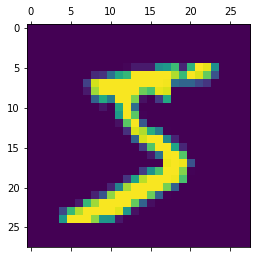

In [30]:
plt.matshow(X_train[0])

In [31]:
y_train[0]

5

<h4 style="color:purple">Normalizing the training data</h4>

In [32]:
# Scale the value
X_train = X_train / 255
X_test = X_test / 255

## 1. Build ANN
<h3 style='color:purple'>Using ANN for classification</h3>

In [33]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
# we have not done the one hot encodig for Y we are using sparse categorical if not we would have used 'catogorical_crossentropy'. Here o/p are 0 to 9 value
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.2764 - accuracy: 0.9224
Epoch 2/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.1267 - accuracy: 0.9625
Epoch 3/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0876 - accuracy: 0.9735
Epoch 4/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0661 - accuracy: 0.9797
Epoch 5/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.0524 - accuracy: 0.9847
Epoch 6/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0426 - accuracy: 0.9868
Epoch 7/10
1875/1875 [==============================] - 4s 2ms/step - loss: 0.0343 - accuracy: 0.9890
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0274 - accuracy: 0.9913
Epoch 9/10
1875/1875 [==============================] - 5s 3ms/step - loss: 0.0230 - accuracy: 0.9929
Epoch 10/10
1875/1875 [==============================] - 6s 3ms/step - loss: 0.020

> Here train set accuracy is just 99.34%

In [34]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 1s 1ms/step - loss: 0.0847 - accuracy: 0.9779


[0.0846812054514885, 0.9779000282287598]

> Here test set accuracy is just 97%

In [35]:
X_train.shape

(60000, 28, 28)

In [36]:
X_train = X_train.reshape(-1,28,28,1)
X_train.shape

(60000, 28, 28, 1)

In [37]:
X_test = X_test.reshape(-1,28,28,1)
X_test.shape

(10000, 28, 28, 1)

## 2. Build CNN
<h3 style='color:purple'>Using CNN for classification</h3>

- In CNN-Conv2D, we will define no of filters (filters=30) to be used, no need to give filter values, it will be set automatically during training
- In CNN-Conv2D, (3, 3) is the kernel_size of filter. Its 3*3 dimension filter


In [38]:
model = keras.Sequential([
    #Convolution layer
    layers.Conv2D(30, (3,3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2,2)), # Here converting output of previous layer from 3*3 dimension to 2*2 dimension by using MaxPooling2D
 
    layers.Flatten(), #Flatten the convolution layer output
    layers.Dense(100, activation='relu'),  # Here we are using flatten data of convolution layer, so no need to mention input size
    keras.layers.Dense(10, activation='sigmoid')
])

In [39]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train, epochs=5)

Epoch 1/5
1875/1875 [==============================] - 23s 12ms/step - loss: 0.1736 - accuracy: 0.9488
Epoch 2/5
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0606 - accuracy: 0.9816
Epoch 3/5
1875/1875 [==============================] - 23s 13ms/step - loss: 0.0395 - accuracy: 0.9874
Epoch 4/5
1875/1875 [==============================] - 21s 11ms/step - loss: 0.0262 - accuracy: 0.9919
Epoch 5/5
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0186 - accuracy: 0.9938


**With CNN, at the end 5 epochs, accuracy was at around 99.38% which is a almost same in CNN and ANN for handwritten image.**

- For color image CNN willl have huge improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features

In [40]:
model.evaluate(X_test,y_test)

313/313 [==============================] - 2s 4ms/step - loss: 0.0462 - accuracy: 0.9852


[0.046185411512851715, 0.9851999878883362]

In [47]:
y_pred = model.predict(X_test)
y_pred[:5]
# predicted test data output

array([[2.2521615e-04, 1.4924046e-01, 8.3370960e-01, 3.2374835e-01,
        1.0079473e-02, 1.4534130e-06, 2.2894010e-07, 1.0000000e+00,
        2.3020923e-02, 1.3707832e-01],
       [5.0159568e-01, 9.5675212e-01, 1.0000000e+00, 8.1548095e-04,
        9.3699992e-03, 8.6482423e-06, 2.1949157e-01, 2.2166984e-07,
        2.0369291e-03, 1.6719103e-03],
       [8.6092949e-04, 9.9996364e-01, 2.7285695e-02, 1.0177508e-06,
        4.4850230e-02, 3.1286478e-04, 3.5191476e-03, 1.4077172e-01,
        1.4975879e-01, 6.6000223e-04],
       [9.9999768e-01, 8.7851286e-04, 1.0837299e-01, 8.5145235e-04,
        2.6761293e-03, 4.3570995e-04, 6.7332280e-01, 9.5736980e-04,
        2.4210274e-02, 6.6685826e-02],
       [1.8775821e-02, 3.6013126e-04, 1.5916377e-02, 2.4840236e-04,
        9.9999893e-01, 4.6148896e-04, 2.2514403e-02, 2.6244015e-02,
        4.7739714e-02, 8.5515386e-01]], dtype=float32)

In [51]:
y_test[:5]
# Original test data output

array([7, 2, 1, 0, 4], dtype=uint8)

In [49]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[7, 2, 1, 0, 4]

> Here both predicted and actual digits are matching

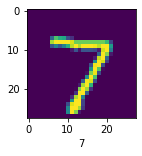

In [57]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(y[index])

plot_sample(X_test, y_test, 0)

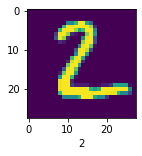

In [58]:
plot_sample(X_test, y_test, 1)

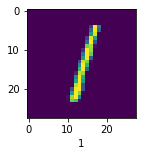

In [59]:
plot_sample(X_test, y_test, 2)

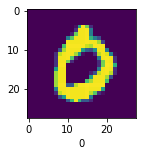

In [60]:
plot_sample(X_test, y_test, 3)

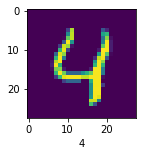

In [61]:
plot_sample(X_test, y_test, 4)